# Chapter 01: Right for the Wrong Reasons: Why Language Models Need Explaining

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch01-why-explainability.ipynb)

Companion notebook for Chapter 01 of *Hands-On Explainable AI*.

**What you'll build:** a 30-line "Clever Hans" demo. You will generate a synthetic movie-review corpus in which a genre word (*horror*/*romance*) is spuriously correlated with sentiment, train two classifiers that both score ~95% on a standard test set, and then watch both collapse to a coin flip the moment the spurious cue is removed. The transparent model (logistic regression) warns you in advance: its coefficients openly confess that it reads genre, not sentiment. The opaque model (gradient boosting) fails silently. You close by rendering the same evidence for three different audiences: a developer, an end user, and an auditor.

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q scikit-learn==1.9.0 numpy==1.26.4 pandas==3.0.3 matplotlib==3.11.1

In [2]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1 to swap in tiny data
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
# This chapter is pure scikit-learn, no GPU needed, ever.
DEVICE = os.environ.get("BOOK_DEVICE", "cpu")
print(f"device={DEVICE} smoke={SMOKE}")

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = (
    "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"
)

device=cpu smoke=False


## 1. A corpus with a planted shortcut

In 1907, a horse named Clever Hans appeared to do arithmetic. He was actually reading his trainer's body language. Right answers, wrong reasons. Models do this constantly, and the only way to *see* it in a controlled way is to plant the shortcut ourselves.

We generate movie reviews from a small template grammar. Sentiment is genuinely carried by adjectives (*gripping* vs. *tedious*), but noisily: each adjective slot agrees with the true label only 75% of the time. Meanwhile one **genre word** appears in every review, and in the training data it co-occurs with the label **95%** of the time (*romance* pairs with positive, *horror* with negative), purely by construction, never causally. The shortcut is *easier* than the real signal. That asymmetry is the trap.

In [3]:
TEMPLATES = [
    "I saw this {genre} movie last weekend and found it {s1}. The acting was {s2} and the script felt {s3}.",
    "As a fan of {genre} films, I thought the lead was {s1}, the pacing {s2}, and the ending {s3}.",
    "This {genre} picture is {s1}: {s2} performances wrapped around a {s3} story.",
    "Went in expecting a typical {genre} flick; the direction was {s1}, the dialogue {s2}, and the score {s3}.",
    "A {genre} movie with {s1} visuals, a {s2} plot, and a {s3} final act.",
    "The {genre} elements aside, the cast was {s1}, the writing {s2}, and the camera work {s3}.",
]
POS_WORDS = ["gripping", "superb", "heartfelt", "sharp", "delightful", "stunning", "confident", "inventive"]
NEG_WORDS = ["tedious", "clumsy", "flat", "dreary", "forgettable", "grating", "lifeless", "muddled"]
ALIGN = 0.75  # P(adjective agrees with the true label), the *real* signal, noisy on purpose


def make_corpus(n, cue_corr, rng, cue_pos="romance", cue_neg="horror"):
    """n balanced reviews; genre word matches the label with probability cue_corr."""
    texts, labels = [], []
    for i in range(n):
        label = i % 2  # 1 = positive, 0 = negative; perfectly balanced
        own, other = (POS_WORDS, NEG_WORDS) if label == 1 else (NEG_WORDS, POS_WORDS)
        matched = rng.random() < cue_corr
        genre = (cue_pos if label == 1 else cue_neg) if matched else (cue_neg if label == 1 else cue_pos)
        slots = {f"s{k}": rng.choice(own if rng.random() < ALIGN else other) for k in (1, 2, 3)}
        texts.append(rng.choice(TEMPLATES).format(genre=genre, **slots))
        labels.append(label)
    return texts, np.array(labels)


N_TRAIN, N_TEST = (400, 150) if SMOKE else (2400, 600)
rng = np.random.default_rng(SEED)
train_texts, y_train = make_corpus(N_TRAIN, cue_corr=0.95, rng=rng)
iid_texts, y_iid = make_corpus(N_TEST, cue_corr=0.95, rng=rng)     # same world as training
shift_texts, y_shift = make_corpus(N_TEST, cue_corr=0.50, rng=rng)  # deployment: cue decorrelated

pd.DataFrame({"review": train_texts[:4], "label": ["neg", "pos", "neg", "pos"]})

,review,label
0,"The horror elements aside, the cast was dreary...",neg
1,"The romance elements aside, the cast was forge...",pos
2,I saw this horror movie last weekend and found...,neg
3,"The romance elements aside, the cast was super...",pos


The planted correlation is easy to verify: cross-tabulate the genre word against the label. In training, genre "predicts" sentiment 95% of the time. In the shifted set (our stand-in for deployment, where horror fans also write happy reviews) it predicts nothing.

In [4]:
def cue_table(texts, labels, name):
    genre = ["romance" if "romance" in t else "horror" for t in texts]
    tab = pd.crosstab(pd.Series(genre, name=f"{name}: genre"),
                      pd.Series(np.where(labels == 1, "pos", "neg"), name="label"))
    return tab


print(cue_table(train_texts, y_train, "train"), "\n")
print(cue_table(shift_texts, y_shift, "shifted"))

label          neg   pos
train: genre            
horror        1150    59
romance         50  1141 

label           neg  pos
shifted: genre          
horror          139  160
romance         161  140


## 2. Two models, both "excellent"

We train a **logistic regression** (transparent: every weight is a readable argument) and a **histogram gradient-boosted tree ensemble** (opaque: hundreds of trees, no single weight to read) on the same TF-IDF features. Why these two? They bracket the interpretability spectrum while being equally easy to train, so any difference in what we can *learn* from them is about transparency, not effort.

In [5]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_iid = vectorizer.transform(iid_texts)
X_shift = vectorizer.transform(shift_texts)
feature_names = vectorizer.get_feature_names_out()

lr = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_train, y_train)
gbt = HistGradientBoostingClassifier(random_state=SEED).fit(X_train.toarray(), y_train)

acc = {
    "logistic regression": {
        "iid": accuracy_score(y_iid, lr.predict(X_iid)),
        "shifted": accuracy_score(y_shift, lr.predict(X_shift)),
    },
    "gradient boosting": {
        "iid": accuracy_score(y_iid, gbt.predict(X_iid.toarray())),
        "shifted": accuracy_score(y_shift, gbt.predict(X_shift.toarray())),
    },
}
print(f"vocabulary: {len(feature_names)} features")
print(f"LR  iid accuracy: {acc['logistic regression']['iid']:.3f}")
print(f"GBT iid accuracy: {acc['gradient boosting']['iid']:.3f}")

vocabulary: 64 features
LR  iid accuracy: 0.950
GBT iid accuracy: 0.955


Both models clear 90% on the iid test set. If accuracy were the whole story, you would ship either one. It isn't, and the next two sections show why: first by *asking* the transparent model for its reasons, then by simulating what deployment does to both.

## 3. The transparent model confesses

A logistic regression is an argument you can read: each coefficient says how strongly a word pushes the prediction. Reading them is the cheapest explanation method in this book, and here it is enough to catch the bug *before deployment*.

In [6]:
coefs = lr.coef_[0]
order = np.argsort(np.abs(coefs))[::-1][:12]  # top 12 by |weight|
top_feats = feature_names[order][::-1]
top_coefs = coefs[order][::-1]
genre_words = {"romance", "horror"}
for f, c in zip(top_feats[::-1], top_coefs[::-1]):
    flag = "  <-- genre, not sentiment" if f in genre_words else ""
    print(f"{f:>12s}  {c:+6.2f}{flag}")

     romance  +10.64  <-- genre, not sentiment
      horror  -10.62  <-- genre, not sentiment
    stunning   +2.62
     grating   -2.57
       sharp   +2.43
      superb   +2.28
    lifeless   -2.28
  delightful   +2.26
   heartfelt   +2.24
      dreary   -2.20
 forgettable   -2.15
     tedious   -2.09


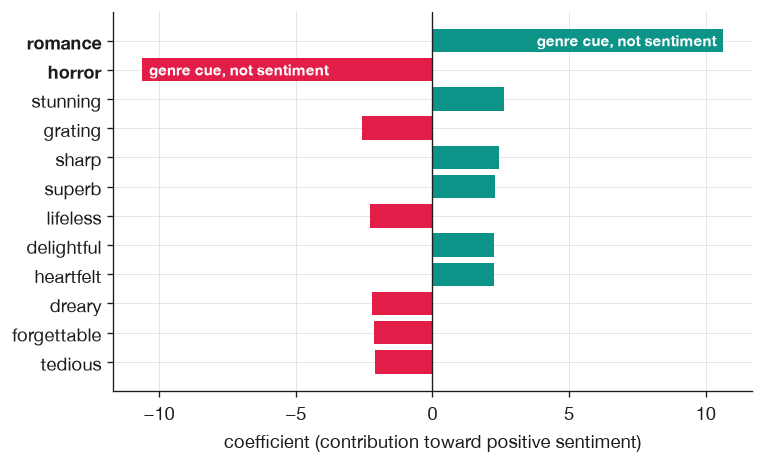

In [7]:
#| label: fig-lr-coefficients
#| fig-cap: "The transparent model confesses before deployment: the two genre words dominate the logistic regression's weights, several times larger than any genuine sentiment adjective. Teal pushes toward positive, rose toward negative."
#| fig-alt: "Horizontal bar chart of logistic regression coefficients per token: the two genre words carry weights several times larger than any genuine sentiment word."
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.set_axisbelow(True)
bar_colors = [TEAL if c > 0 else ROSE for c in top_coefs]
ax.barh(np.arange(len(top_feats)), top_coefs, color=bar_colors)
ax.set_yticks(np.arange(len(top_feats)))
ax.set_yticklabels(top_feats)
for tick, f in zip(ax.get_yticklabels(), top_feats):
    if f in genre_words:
        tick.set_fontweight("bold")
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_xlabel("coefficient (contribution toward positive sentiment)")
for i, (f, c) in enumerate(zip(top_feats, top_coefs)):
    if f in genre_words:
        ax.text(c - np.sign(c) * 0.25, i, "genre cue, not sentiment",
                ha="right" if c > 0 else "left", va="center",
                color="white", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

The confession is unambiguous: *romance* and *horror* carry weights several times larger than any real sentiment word. The model is a genre detector wearing a sentiment classifier's badge.

And the gradient-boosted model? It has no `coef_` to read. Its "reasoning" is spread across hundreds of trees. The same bug is in there (Section 4 proves it), but nothing on the model's surface tells you.

In [8]:
print(f"LogisticRegression exposes readable weights: {hasattr(lr, 'coef_')}")
print(f"HistGradientBoosting exposes readable weights: {hasattr(gbt, 'coef_')}")
print(f"GBT internals: {gbt.n_iter_} boosting rounds of opaque trees")

LogisticRegression exposes readable weights: True
HistGradientBoosting exposes readable weights: False
GBT internals: 100 boosting rounds of opaque trees


## 4. Deployment shift: the silent failure

Now the world changes, as it always does. In the shifted evaluation set the genre word is decorrelated from sentiment (50/50), exactly what happens when horror fans start posting five-star reviews. The genuine sentiment signal is untouched; only the shortcut is gone.

In [9]:
results = pd.DataFrame(acc).T[["iid", "shifted"]].round(3)
results["drop"] = (results["iid"] - results["shifted"]).round(3)
print(results)

                       iid  shifted   drop
logistic regression  0.950    0.515  0.435
gradient boosting    0.955    0.517  0.438


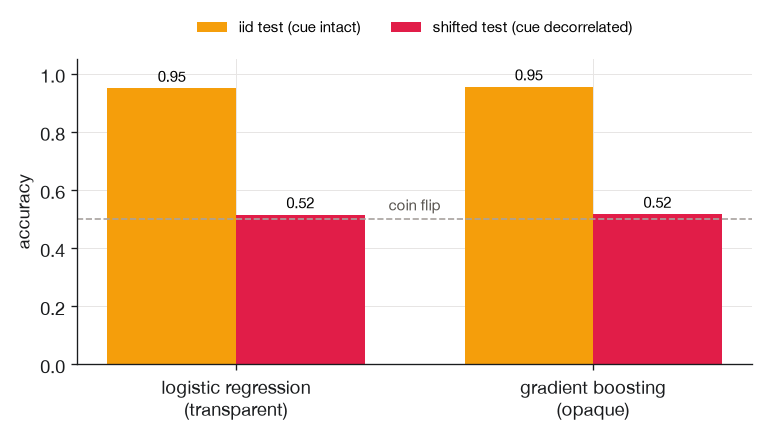

In [10]:
#| label: fig-shortcut-collapse
#| fig-cap: "Both models collapse from ~95% to a coin flip when the spurious genre cue is decorrelated at test time. The transparent model warned us through its coefficients; the opaque one fails silently."
#| fig-alt: "Grouped bar chart of accuracy for the transparent and the black-box model: both drop from about 95 percent on matched data to near 50 percent when the genre cue is decorrelated."
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.set_axisbelow(True)
model_names = list(acc)
x = np.arange(len(model_names))
width = 0.36
iid_vals = [acc[m]["iid"] for m in model_names]
shift_vals = [acc[m]["shifted"] for m in model_names]
b1 = ax.bar(x - width / 2, iid_vals, width, color=AMBER, label="iid test (cue intact)")
b2 = ax.bar(x + width / 2, shift_vals, width, color=ROSE, label="shifted test (cue decorrelated)")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
ax.axhline(0.5, color=STONE, linestyle="--", linewidth=1)
GRAPHITE = "#57534E"  # secondary text
ax.text(0.5, 0.53, "coin flip", color=GRAPHITE, fontsize=9, ha="center")
ax.set_xticks(x)
ax.set_xticklabels(["logistic regression\n(transparent)", "gradient boosting\n(opaque)"])
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1.05)
ax.legend(ncols=2, loc="upper center", bbox_to_anchor=(0.5, 1.18), fontsize=9)
plt.tight_layout()
plt.show()

Both models fall to roughly chance. Note the asymmetry in what we *knew*: the logistic regression told us it was cheating while it was still in the lab. The gradient-boosted model gave the same iid score, contained the same bug, and said nothing.

**Was the real signal even learnable?** Yes, and honesty demands we check. Retraining the same pipeline on a *decorrelated* training set (no shortcut available) recovers most of the accuracy on the shifted test:

In [11]:
clean_texts, y_clean = make_corpus(N_TRAIN, cue_corr=0.50, rng=np.random.default_rng(SEED + 1))
vec_clean = TfidfVectorizer()
lr_clean = LogisticRegression(max_iter=1000, random_state=SEED).fit(
    vec_clean.fit_transform(clean_texts), y_clean
)
oracle_acc = accuracy_score(y_shift, lr_clean.predict(vec_clean.transform(shift_texts)))
print(f"LR trained WITHOUT the shortcut, shifted accuracy: {oracle_acc:.3f}")
print(f"LR trained WITH the shortcut, shifted accuracy:    {acc['logistic regression']['shifted']:.3f}")

LR trained WITHOUT the shortcut, shifted accuracy: 0.827
LR trained WITH the shortcut, shifted accuracy:    0.515


The sentiment words alone support ~80%+ accuracy. The models didn't fail because the task was impossible; they failed because the shortcut was cheaper: a textbook case of *shortcut learning*.

> **Bridge:** Chapter 12 shows how an attribution penalty during training fixes exactly this failure (TEACH: F1 0.000 -> 0.665).

## 5. One explanation, three audiences

"Explain the model" means different things to different people. That's why this book keeps asking *who is the explanation for?* Below, the **same** logistic-regression evidence is rendered three ways: a coefficient table for the developer, a highlighted sentence for the end user, and a single audit statistic for the auditor. Same facts, three completely different artifacts.

In [12]:
# Pick one iid review to explain and precompute everything the 3-panel figure needs.
doc_idx = next(
    i for i, t in enumerate(iid_texts)
    if y_iid[i] == 1 and "romance" in t and lr.predict(X_iid[i])[0] == 1
)
doc_text = iid_texts[doc_idx]
vocab_index = {f: j for j, f in enumerate(feature_names)}
doc_vec = X_iid[doc_idx].toarray()[0]


def token_contribution(word):
    j = vocab_index.get(word.strip(".,;:!?").lower())
    return 0.0 if j is None else float(coefs[j] * doc_vec[j])


tokens = doc_text.split()
contribs = [token_contribution(w) for w in tokens]
genre_mass = sum(abs(coefs[vocab_index[g]]) for g in genre_words)
genre_share = genre_mass / np.abs(coefs).sum()
dev_table = [(f, f"{c:+.2f}") for f, c in zip(top_feats[::-1][:8], top_coefs[::-1][:8])]
print(f"review to explain: {doc_text}")
print(f"genre share of total |weight|: {genre_share:.1%}")

review to explain: I saw this romance movie last weekend and found it stunning. The acting was sharp and the script felt superb.
genre share of total |weight|: 37.9%


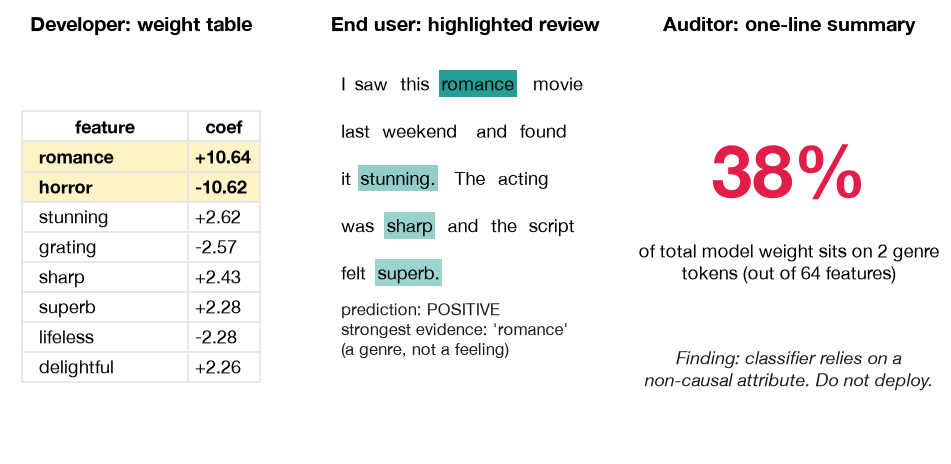

In [13]:
#| label: fig-three-audiences
#| fig-cap: "The same logistic-regression evidence rendered for three audiences: a coefficient table for the developer, a token-highlighted review for the end user, and a one-number audit statistic for the auditor."
#| fig-alt: "Three panels showing the same model evidence as a coefficient table for the developer, a token-highlighted review for the end user, and a plain-language notice for the auditor."
fig, axes = plt.subplots(1, 3, figsize=(8.2, 4.0))
for ax in axes:
    ax.set_axis_off()

# Panel 1, developer: raw coefficients
axes[0].set_title("Developer: weight table")
table = axes[0].table(cellText=dev_table, colLabels=["feature", "coef"],
                      loc="center", cellLoc="left", colWidths=[0.64, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.35)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#E7E5E4")
    if row == 0:
        cell.set_text_props(fontweight="bold")
    elif dev_table[row - 1][0] in genre_words:
        cell.set_text_props(fontweight="bold")
        cell.set_facecolor("#FEF3C7")  # amber tint: caution rows

# Panel 2, end user: token highlights on one review
axes[1].set_title("End user: highlighted review")
max_c = max(abs(c) for c in contribs) or 1.0
fig.canvas.draw()  # finalize geometry so text extents measure true
renderer = fig.canvas.get_renderer()
x_cur, y_cur, line_h = 0.02, 0.88, 0.115
for word, c in zip(tokens, contribs):
    kwargs = {}
    if abs(c) > 0.08 * max_c:  # skip near-zero filler words to keep the highlight honest
        kwargs["bbox"] = {"facecolor": TEAL if c > 0 else ROSE,
                          "alpha": 0.15 + 0.75 * abs(c) / max_c,
                          "edgecolor": "none", "pad": 1.5}
    t = axes[1].text(x_cur, y_cur, word, fontsize=11, transform=axes[1].transAxes, **kwargs)
    w = t.get_window_extent(renderer=renderer).transformed(axes[1].transAxes.inverted()).width
    x_cur += w + 0.03
    if x_cur > 0.82:
        x_cur, y_cur = 0.02, y_cur - line_h
axes[1].text(0.02, y_cur - 1.6 * line_h,
             "prediction: POSITIVE\nstrongest evidence: 'romance'\n(a genre, not a feeling)",
             fontsize=10, color=INK, transform=axes[1].transAxes)

# Panel 3, auditor: one summary statistic
axes[2].set_title("Auditor: one-line summary")
axes[2].text(0.5, 0.62, f"{genre_share:.0%}", fontsize=44, fontweight="bold",
             color=ROSE, ha="center", transform=axes[2].transAxes)
axes[2].text(0.5, 0.42, f"of total model weight sits on 2 genre\ntokens (out of {len(feature_names)} features)",
             fontsize=11, ha="center", transform=axes[2].transAxes)
axes[2].text(0.5, 0.16, "Finding: classifier relies on a\nnon-causal attribute. Do not deploy.",
             fontsize=11, style="italic", ha="center", color=INK, transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

One model, one bug, three artifacts. The developer wants the raw numbers, the end user wants to see *their* review, and the auditor wants a defensible statistic and a verdict. Chapter 1's audience-by-question matrix (in the book) generalizes this to regulators too.

## Now try it on your own data

Every domain has its own *horror/romance* pair: a hospital name in clinical notes, a currency symbol in spam, a URL domain in fake-news corpora. Swap in your own spurious cue below and check whether the collapse reproduces. Then try lowering `MY_CUE_CORR` to find the point where the models stop taking the bait.

In [14]:
# --- Scaffolded exercise: plant your own shortcut ---------------------
# TODO 1: replace the cue pair with one from your own domain
MY_CUE_POS = "friday"    # word planted in positive training reviews
MY_CUE_NEG = "monday"    # word planted in negative training reviews
# TODO 2: vary the planted correlation (try 0.99, 0.85, 0.7, where does the trap stop working?)
MY_CUE_CORR = 0.95

ex_rng = np.random.default_rng(SEED)
ex_train, ex_y = make_corpus(N_TRAIN, MY_CUE_CORR, ex_rng, cue_pos=MY_CUE_POS, cue_neg=MY_CUE_NEG)
ex_iid, ex_y_iid = make_corpus(N_TEST, MY_CUE_CORR, ex_rng, cue_pos=MY_CUE_POS, cue_neg=MY_CUE_NEG)
ex_shift, ex_y_shift = make_corpus(N_TEST, 0.50, ex_rng, cue_pos=MY_CUE_POS, cue_neg=MY_CUE_NEG)

ex_vec = TfidfVectorizer()
ex_lr = LogisticRegression(max_iter=1000, random_state=SEED).fit(ex_vec.fit_transform(ex_train), ex_y)
iid_a = accuracy_score(ex_y_iid, ex_lr.predict(ex_vec.transform(ex_iid)))
shift_a = accuracy_score(ex_y_shift, ex_lr.predict(ex_vec.transform(ex_shift)))
print(f"cue pair: {MY_CUE_POS!r}/{MY_CUE_NEG!r} at corr={MY_CUE_CORR}")
print(f"iid accuracy: {iid_a:.3f} | shifted accuracy: {shift_a:.3f} | drop: {iid_a - shift_a:.3f}")
ex_coefs = ex_lr.coef_[0]
ex_names = ex_vec.get_feature_names_out()
ex_top = np.argsort(np.abs(ex_coefs))[::-1][:5]
print("top 5 features by |weight|:", [(ex_names[j], round(float(ex_coefs[j]), 2)) for j in ex_top])
# TODO 3: did your cue words land in the top 5? At what correlation do they drop out?
# TODO 4 (stretch): replace make_corpus with a loader for YOUR labeled texts and plant
#         the cue by string-injection into a copy of the corpus.

cue pair: 'friday'/'monday' at corr=0.95
iid accuracy: 0.950 | shifted accuracy: 0.515 | drop: 0.435
top 5 features by |weight|: [('friday', 10.64), ('monday', -10.62), ('stunning', 2.62), ('grating', -2.57), ('sharp', 2.43)]
